# Strategically Robust Trajectory Optimization

Agents planning around each other have to guess what the others will do. A
nominal plan assumes those guesses are right. This notebook works through what
changes when each agent instead plans against the *worst* deviation the others
could make, at every step of the horizon.

The comparison is deliberately three-way, because the obvious objection to
robustness is that it is just timidity with extra steps:

| method | collision cost evaluated at | weight |
|---|---|---|
| **nominal** | the trajectory as planned | $c_1 = 2$ |
| **wider** | the trajectory as planned | $c_1 = 5$ |
| **strategically robust** | the worst case, every step | $c_1 = 2$ |

"Wider" is the naive way to buy separation: leave the model alone and turn the
penalty up. If robustness were only timidity, wider would reproduce it. The
figures below show it does not — the two bend the trajectory in different
places, and buy different amounts of worst-case margin per unit of deviation
from the nominal plan.

**Runtime.** About 12 minutes end to end. The 8-agent scenario dominates: its
nominal solve alone takes ~45 s, and the timing section repeats it. `BENCH_RUNS`
and `BENCH_RUNS_8` below control how many repetitions that section takes.

## 0. Setup

The repository root holds the solver modules; this cell makes them importable
whether Jupyter was started from the root or from `notebooks/`.

In [1]:
import pathlib
import sys

ROOT = pathlib.Path.cwd()
if not (ROOT / 'solvers.py').exists():          # started from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FIGDIR = ROOT / 'figures'
FIGDIR.mkdir(exist_ok=True)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import plot_style
import plotting
from costs import ALPHA, C1_NOMINAL, C1_WIDER, make_cost
from solvers import (optimize_everystep, optimize_everystep_shooting,
                     optimize_optimal, optimize_optimal_shooting, split_solution)

plot_style.apply()
pd.set_option('display.precision', 4)

# Number of timed repetitions in the runtime section.  The paper uses 30 for the
# small scenarios and 10 for 8 agents; these are lowered so the notebook runs in
# minutes.  Ratios are stable at this count -- the absolute times are not.
BENCH_RUNS = 5
BENCH_RUNS_8 = 3

### The cost

Each agent tracks its own goal and is penalised for being close to anyone else:

$$
J = \sum_i \Big[ (x_{i,H} - x_i^f)^\top Q_f (x_{i,H} - x_i^f)
  + \sum_{t<H} (x_{i,t} - x_i^f)^\top Q (x_{i,t} - x_i^f) + u_{i,t}^\top R\, u_{i,t} \Big]
  \; + \sum_{i<j} \sum_t f\big(\|p_{i,t} - p_{j,t}\|\big)
$$

with the log-barrier pair cost $f(d) = -c_1 \log(d^2 + \alpha)$, which diverges
as $d \to 0$. `make_cost` returns $f$ and $f'$ together — passing a cost without
its derivative silently drops SLSQP into finite differences, which is not just
slower but tends to stop somewhere worse.

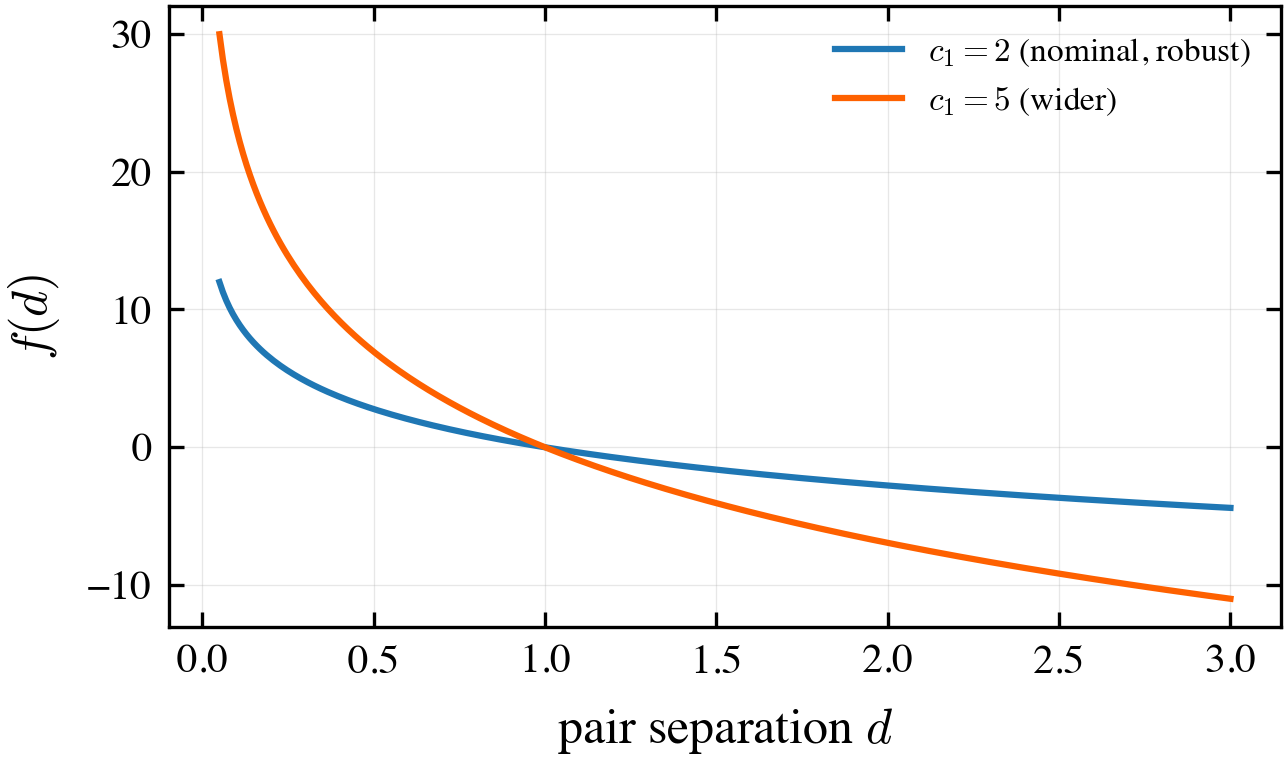

In [2]:
cost_nominal, grad_nominal = make_cost('logarithmic', c1=C1_NOMINAL, alpha=ALPHA)
cost_wider, grad_wider = make_cost('logarithmic', c1=C1_WIDER, alpha=ALPHA)

d = np.linspace(0.05, 3.0, 300)
fig, ax = plt.subplots(figsize=(plotting.PANEL * 1.3, plotting.PANEL * 0.8))
ax.plot(d, cost_nominal(d), color=plot_style.BLUE, label=f'$c_1 = {C1_NOMINAL:g}$ (nominal, robust)')
ax.plot(d, cost_wider(d), color=plot_style.ORANGE, label=f'$c_1 = {C1_WIDER:g}$ (wider)')
ax.set_xlabel('pair separation $d$')
ax.set_ylabel('$f(d)$')
ax.grid(True, linewidth=0.3, alpha=0.3)
ax.tick_params(direction='in', top=True, right=True)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## 1. Head-on: two agents swapping places

Single-integrator dynamics, $A = I$, $B = \Delta t\, I$, horizon $H = 20$ over
2 seconds. The two agents start 2 apart and must exchange positions, so the
straight-line plans intersect. The 0.1 offset in $y$ breaks the symmetry —
without it the problem has two mirror-image optima and the solver picks one
arbitrarily.

In [3]:
H, tf, eps = 20, 2.0, 2.0
dt = tf / H
n_a, sdim, cdim, pdim = 2, 2, 2, 2

A = np.eye(sdim)
B = dt * np.eye(cdim)
Q = np.eye(sdim)
Qf = 150.0 * np.eye(sdim)
R = np.eye(cdim)

x0 = np.array([[0.0, 1.1], [2.0, 1.0]])
xf = np.array([[2.0, 1.0], [0.0, 1.1]])

problem = (x0, xf, A, B, H, Q, R, Qf, n_a, sdim, cdim, pdim)
print(f'{n_a} agents, H = {H}, dt = {dt}, eps = {eps}')
print(f'decision variables: {n_a * (H + 1) * sdim + n_a * H * cdim}, '
      f'equality constraints: {n_a * sdim + n_a * H * sdim}')

2 agents, H = 20, dt = 0.1, eps = 2.0
decision variables: 164, equality constraints: 84


### The three solves

The robust solve is warm-started from the nominal one, which is both faster and
what the runtime tables charge it for.

In [4]:
import time

t0 = time.perf_counter()
res_nominal = optimize_optimal(*problem, cost_nominal, distance_cost_grad_func=grad_nominal)
t_nominal = time.perf_counter() - t0
x_nom, u_nom = split_solution(res_nominal, n_a, H, sdim, cdim)

t0 = time.perf_counter()
res_wider = optimize_optimal(*problem, cost_wider, distance_cost_grad_func=grad_wider,
                             x_opt=x_nom, u_opt=u_nom)
t_wider = time.perf_counter() - t0

t0 = time.perf_counter()
res_robust = optimize_everystep(*problem, eps, cost_nominal,
                                distance_cost_grad_func=grad_nominal,
                                x_opt=x_nom, u_opt=u_nom)
t_robust = time.perf_counter() - t0

RESULTS = [res_nominal, res_wider, res_robust]
LABELS = ['nominal', 'wider', 'strat. robust']

pd.DataFrame([
    {'method': lab, 'objective': r.fun, 'iterations': r.nit,
     'function evals': r.nfev, 'seconds': t, 'converged': bool(r.success)}
    for lab, r, t in zip(LABELS, RESULTS, [t_nominal, t_wider, t_robust])
]).set_index('method')

,objective,iterations,function evals,seconds,converged
method,,,,,
nominal,73.3080,31,47,0.6146,True
wider,8.3905,12,23,0.0823,True
strat. robust,116.4260,13,23,0.1835,True


The objectives are **not comparable across rows** — each is the value of a
different function. Wider's is far lower simply because a larger $c_1$ scales
the (negative) barrier term; robust's is higher because it is evaluated at
perturbed positions that are closer together than the planned ones. What is
comparable is the geometry, which is what the rest of the notebook measures.

## 2. The trajectories

Color is the agent, dash pattern is the method.

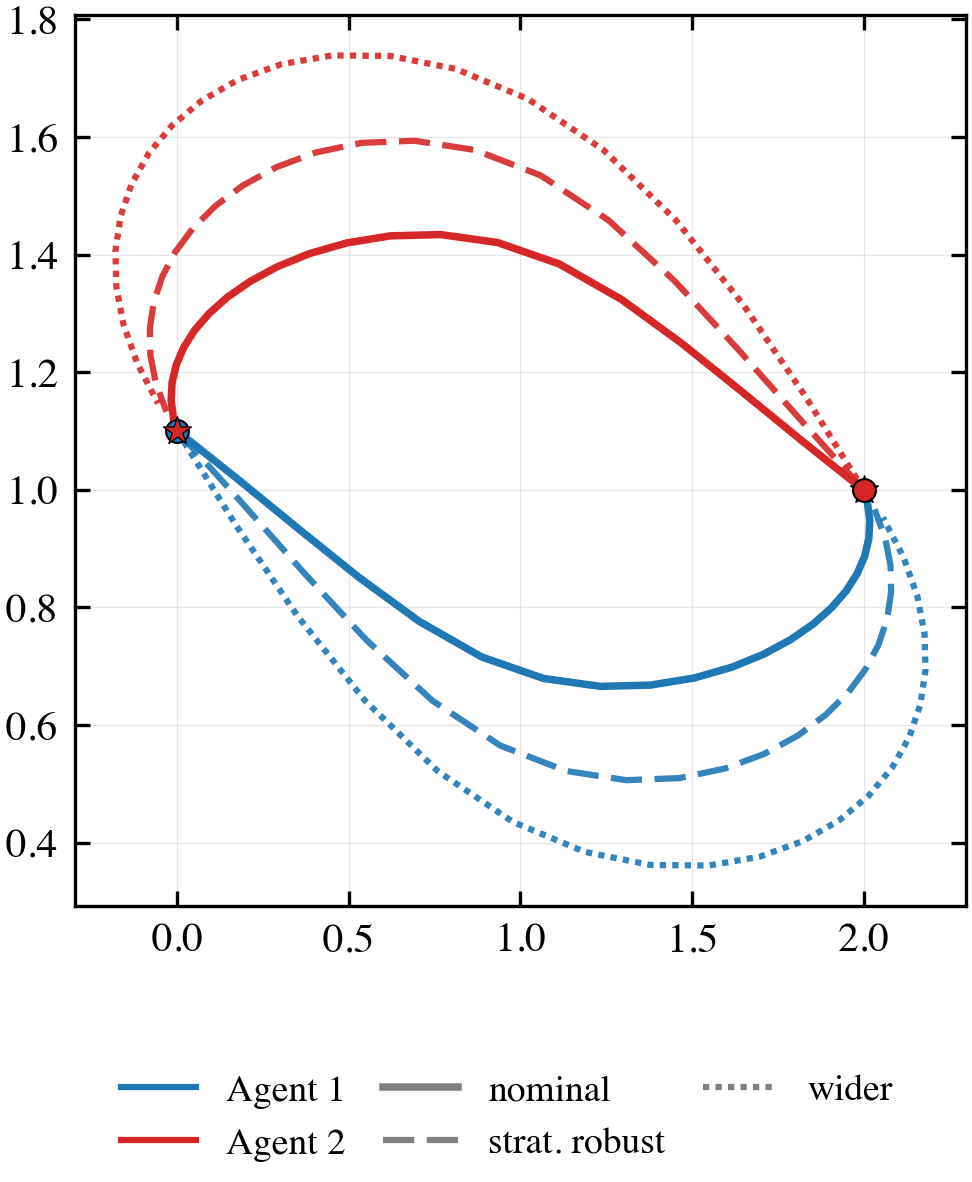

In [5]:
plotting.plot_trajectories(res_nominal, [res_robust, res_wider], n_a, H, sdim, cdim, xf,
                           method_labels=LABELS[:1] + ['strat. robust', 'wider'],
                           save_path=FIGDIR / 'headon_trajectories.png')
plt.show()

Both alternatives bow further out than the nominal plan, and wider bows
furthest. Distance from the nominal path is not the quantity of interest,
though — a plan can be far from nominal and still fragile. Section 4 measures
what each one is actually buying.

## 3. Relative coordinates

For a pair, only the relative state $z_t = x_{i,t} - x_{j,t}$ matters: the
origin *is* the collision. Solid curves are the plans as flown; dashed curves
are where an adversary with energy budget $\varepsilon = 2$ can drag them, one
point per horizon prefix.

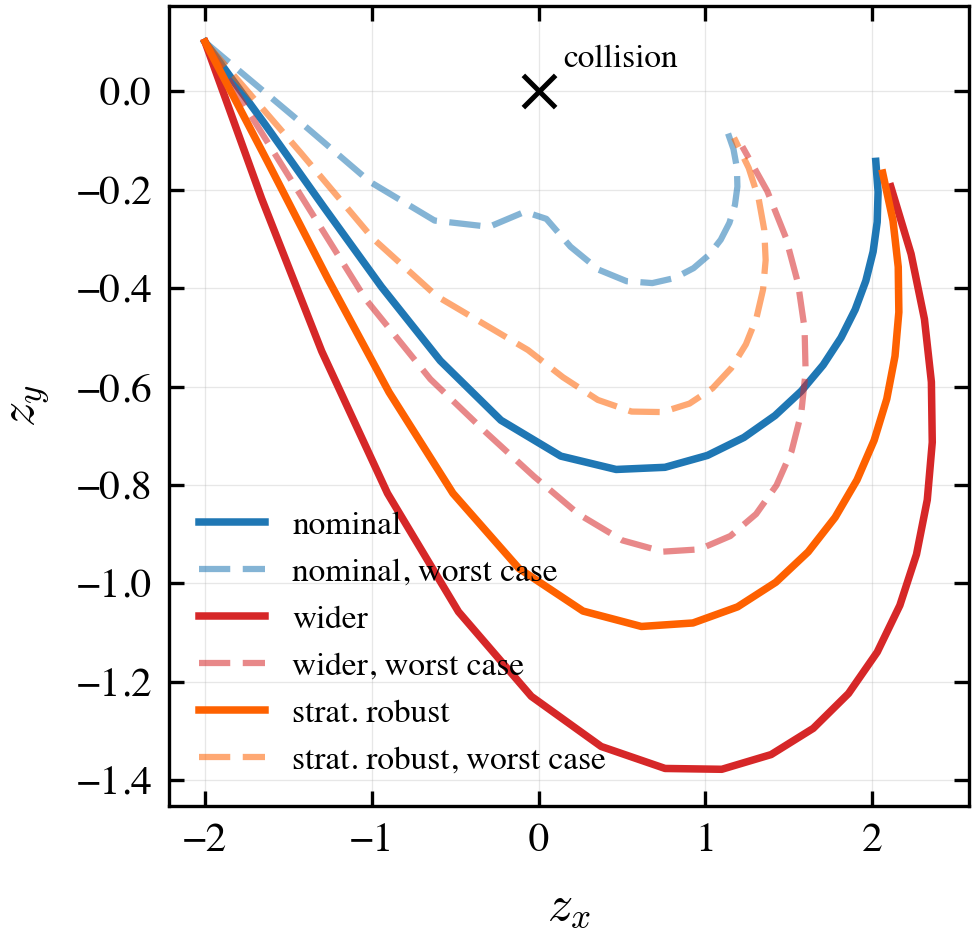

In [6]:
plotting.plot_relative_trajectory(RESULTS, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B,
                                  save_path=FIGDIR / 'headon_relative.png')
plt.show()

## 4. What the adversary can take away

The gap between a method's solid and dashed curve above — and between its two
curves below — is the margin an adversary can erase. A robust plan is one whose
*dashed* curve stays up. Its solid curve need not be the highest.

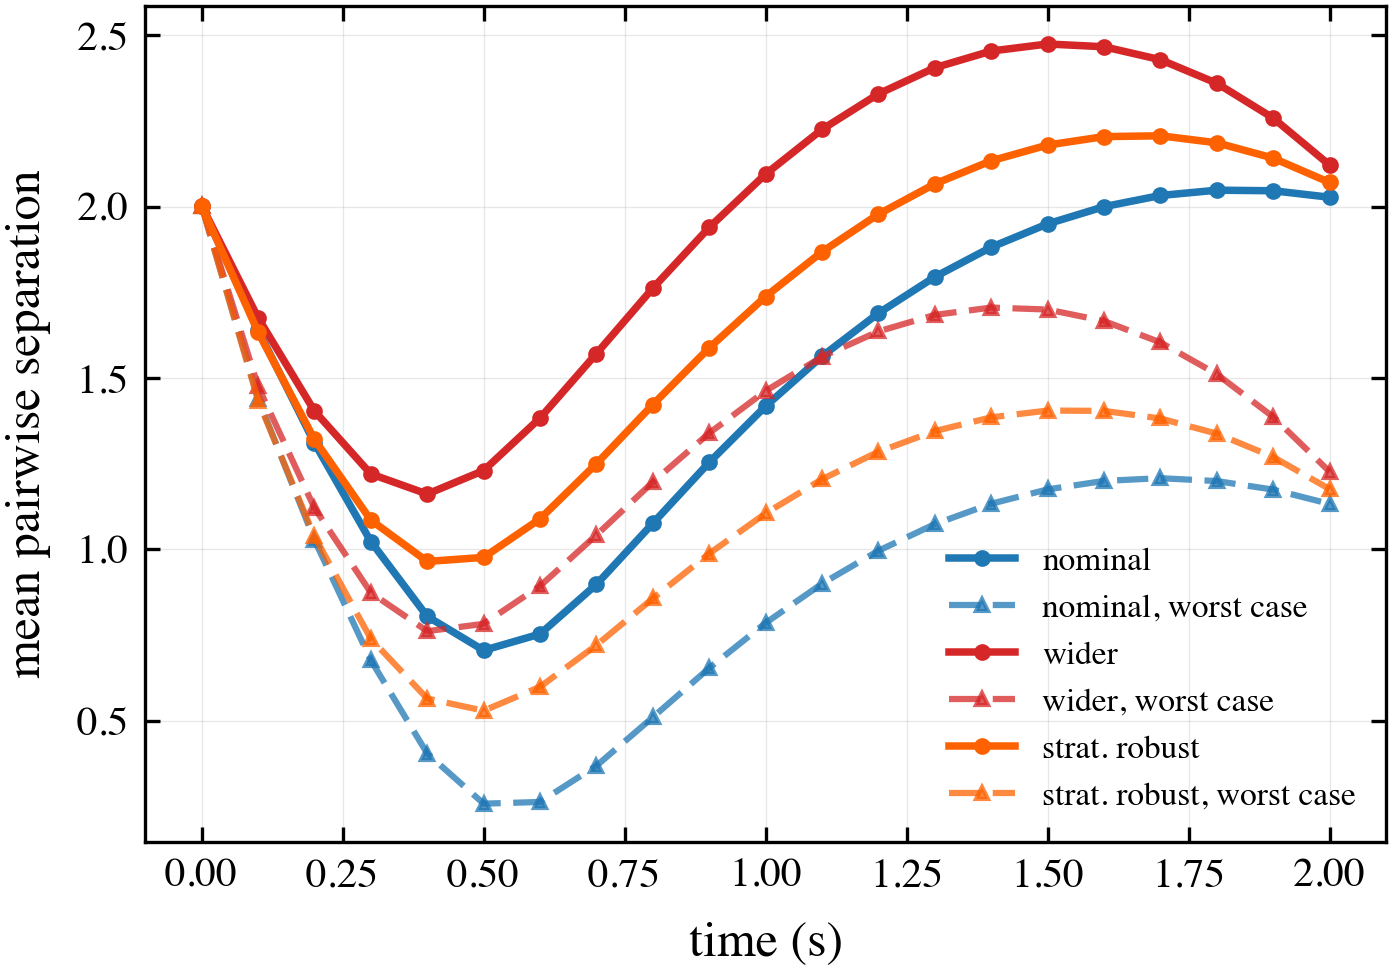

In [7]:
plotting.plot_avg_distances(RESULTS, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B, dt,
                            save_path=FIGDIR / 'headon_separation.png')
plt.show()

In [8]:
sep = pd.DataFrame(plotting.min_separation_table(
    RESULTS, LABELS, n_a, H, sdim, cdim, pdim, eps, A, B)).set_index('method')
sep['worst-case margin vs nominal'] = (
    sep['min separation, worst case'] / sep.loc['nominal', 'min separation, worst case'])
sep

,min separation,"min separation, worst case",worst-case margin vs nominal
method,,,
nominal,0.7056,0.2583,1.0000
wider,1.1615,0.7615,2.9477
strat. robust,0.9649,0.5295,2.0497


## 5. Robustness is not a larger penalty

Both alternatives improve the worst case. The question is what each pays for it.
Integrated path deviation is the area between a method's trajectory and the
nominal one, averaged over agents — a direct measure of how much the plan had to
be distorted.

In [9]:
import benchmark_tables as bench

trade = []
for lab, res in zip(LABELS, RESULTS):
    x = split_solution(res, n_a, H, sdim, cdim)[0]
    trade.append({
        'method': lab,
        'path deviation': bench.integrated_path_deviation(x, x_nom, dt, pdim),
        'min separation, worst case': sep.loc[lab, 'min separation, worst case'],
    })
trade = pd.DataFrame(trade).set_index('method')
gain = trade['min separation, worst case'] - trade.loc['nominal', 'min separation, worst case']
trade['worst-case gain'] = gain
trade['gain per unit deviation'] = (gain / trade['path deviation']).replace([np.inf, -np.inf], np.nan)
trade

,path deviation,"min separation, worst case",worst-case gain,gain per unit deviation
method,,,,
nominal,0.0000,0.2583,0.0000,NaN
wider,0.5159,0.7615,0.5032,0.9754
strat. robust,0.2523,0.5295,0.2712,1.0748


The two are not interchangeable, but the difference is a trade rather than a
dominance. On this scenario the wider penalty buys *more* absolute worst-case
margin than robustness does — and pays more than twice the path deviation for
it. Per unit of distortion the two land within about 10% of each other, and
section 7 shows the ordering is not even stable across scenarios.

What does not trade away is where the number comes from. Wider's margin is set
by $c_1$, a tuning constant with no operational meaning: nothing tells you which
value corresponds to which level of protection, and the mapping moves with the
scenario. The robust margin is set by $\varepsilon$ — the disturbance energy the
plan is required to absorb, stated up front, in units. One is a knob you turn
until the picture looks safe; the other is an assumption you can defend.

## 6. Animation

Written to `figures/` and embedded as a GIF rather than as inline JavaScript;
the JavaScript form is what turns a notebook into a multi-megabyte file.

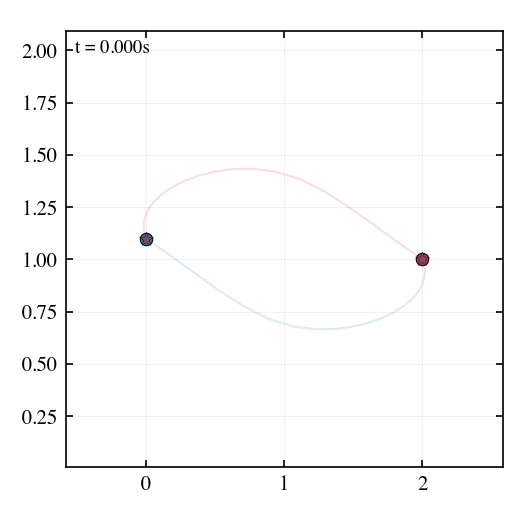

In [10]:
fig, anim = plotting.animate_trajectories(
    res_nominal, [res_robust], n_a, H, sdim, cdim, xf, dt,
    save_path=FIGDIR / 'headon_animation.gif')
plt.close(fig)
display(Image(filename=str(FIGDIR / 'headon_animation.gif')))

## 7. Four agents

Six pairs instead of one, and the interaction is no longer a single crossing:
agents must resolve conflicts with several neighbours at once. Everything below
is the same code with a different scenario.

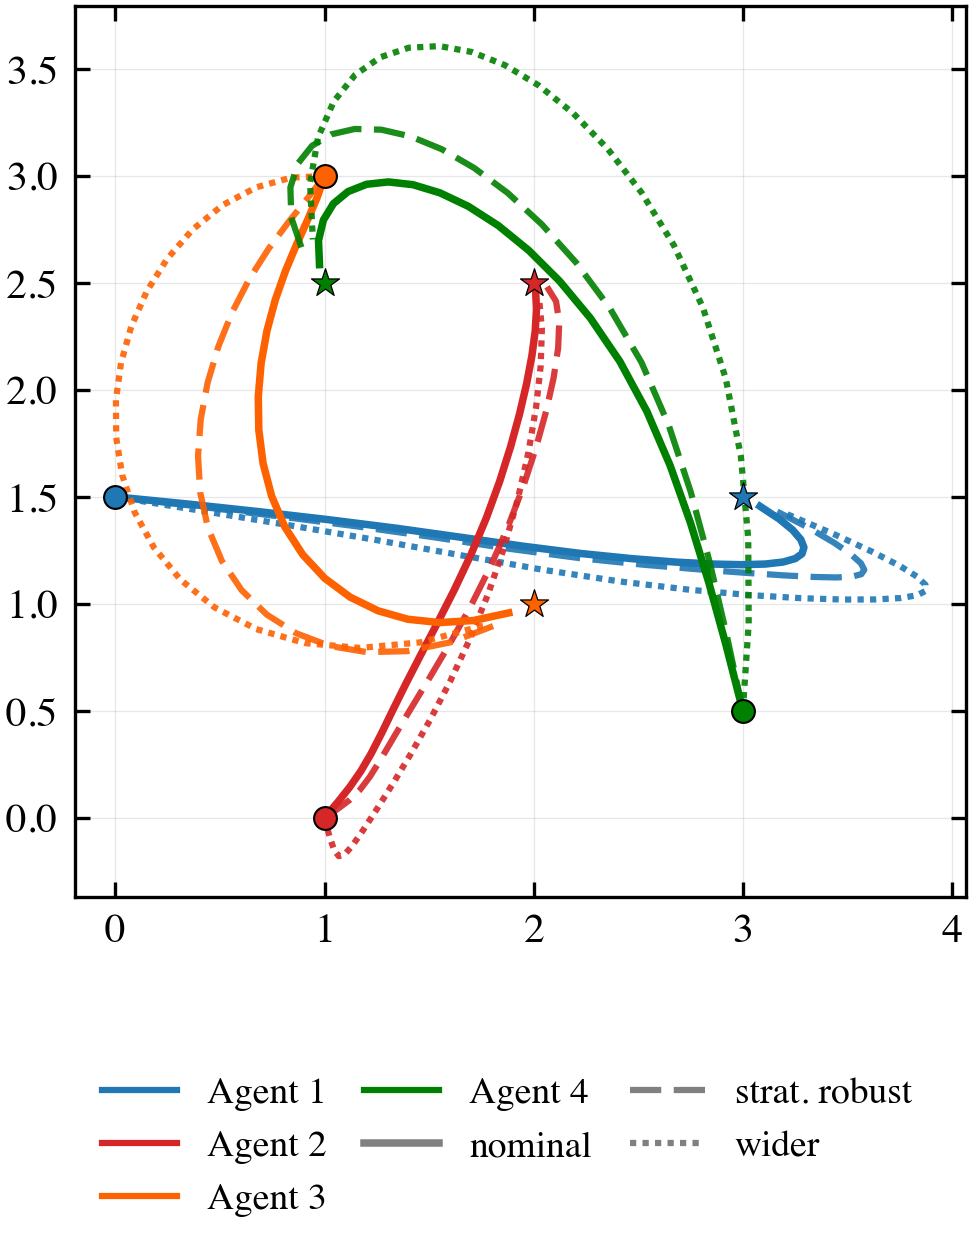

In [11]:
n_a4 = 4
x0_4 = np.array([[0.0, 1.5], [1.0, 0.0], [1.0, 3.0], [3.0, 0.5]])
xf_4 = np.array([[3.0, 1.5], [2.0, 2.5], [2.0, 1.0], [1.0, 2.5]])
problem4 = (x0_4, xf_4, A, B, H, Q, R, Qf, n_a4, sdim, cdim, pdim)

res4_nominal = optimize_optimal(*problem4, cost_nominal, distance_cost_grad_func=grad_nominal)
x4_nom, u4_nom = split_solution(res4_nominal, n_a4, H, sdim, cdim)
res4_wider = optimize_optimal(*problem4, cost_wider, distance_cost_grad_func=grad_wider,
                              x_opt=x4_nom, u_opt=u4_nom)
res4_robust = optimize_everystep(*problem4, eps, cost_nominal,
                                 distance_cost_grad_func=grad_nominal,
                                 x_opt=x4_nom, u_opt=u4_nom)
RESULTS4 = [res4_nominal, res4_wider, res4_robust]

plotting.plot_trajectories(res4_nominal, [res4_robust, res4_wider], n_a4, H, sdim, cdim, xf_4,
                           method_labels=['nominal', 'strat. robust', 'wider'],
                           save_path=FIGDIR / '4agent_trajectories.png')
plt.show()

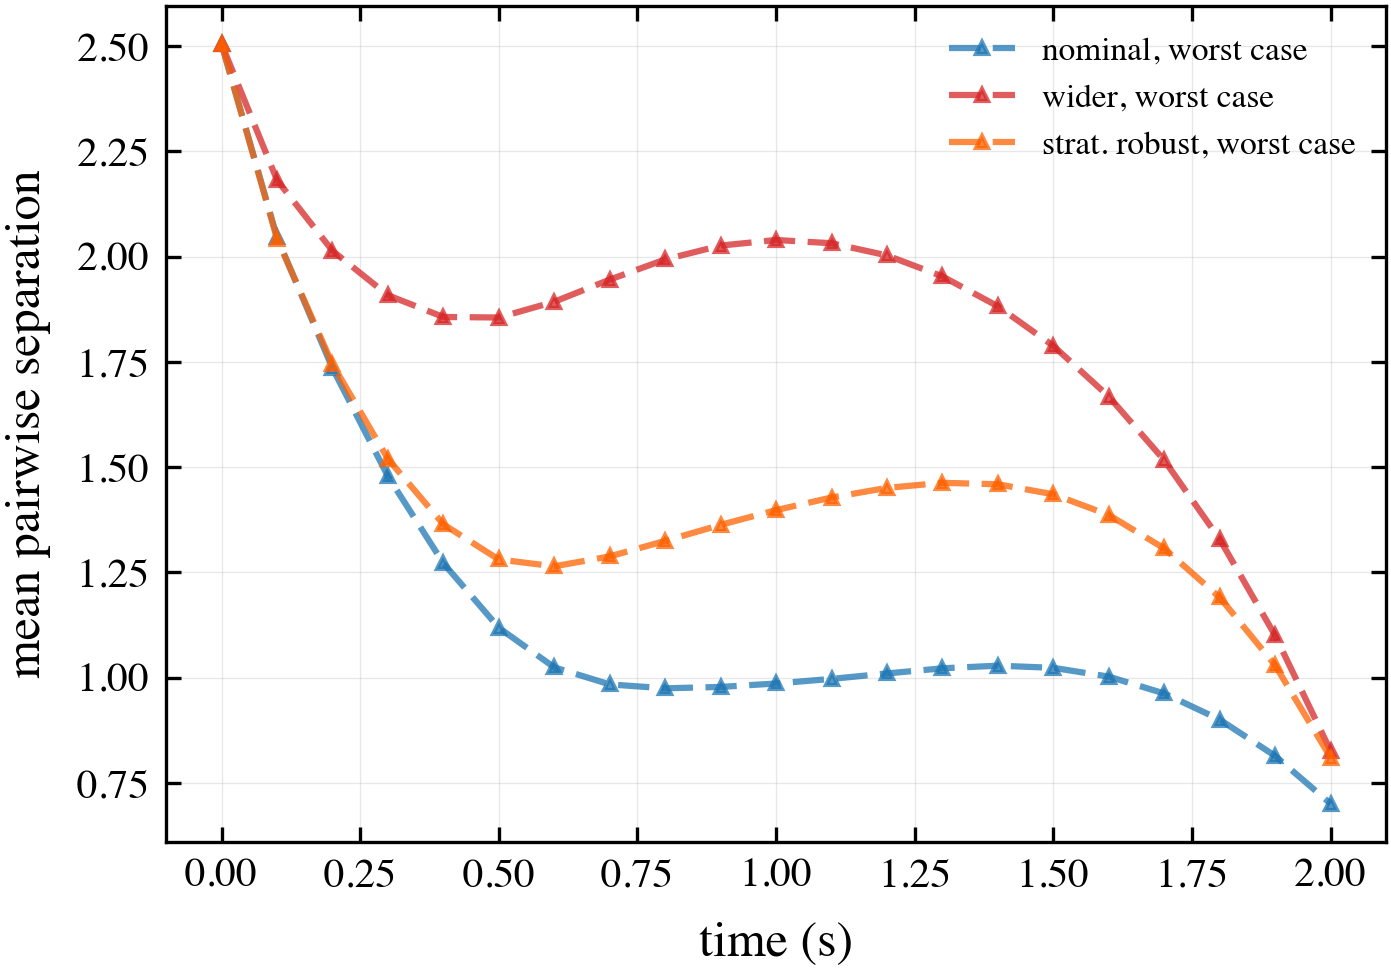

,min separation,"min separation, worst case"
method,,
nominal,0.9652,0.1470
wider,1.1153,0.2209
strat. robust,1.0753,0.2790


In [12]:
plotting.plot_avg_distances(RESULTS4, LABELS, n_a4, H, sdim, cdim, pdim, eps, A, B, dt,
                            show_nominal=False,
                            save_path=FIGDIR / '4agent_separation.png')
plt.show()

pd.DataFrame(plotting.min_separation_table(
    RESULTS4, LABELS, n_a4, H, sdim, cdim, pdim, eps, A, B)).set_index('method')

Read those two outputs against each other, because they disagree.

On the **mean** worst-case separation the wider penalty sits well above the
robust solve. On the **minimum** over all six pairs and every step — the
quantity a safety claim actually rests on — the ordering reverses, and
robustness wins on both axes at once: a larger worst-case margin for less than
half the path deviation.

The mean is what hides it. Averaging over six pairs lets slack in five of them
cover a tight sixth, and a wider penalty buys exactly that kind of slack — it
pushes every pair apart uniformly, including the ones that were never in
danger. The robust solve spends its distortion where the adversary would
actually attack.

## 8. Eight agents on a circle

The stress case: eight agents evenly spaced on a circle of radius 2, each
heading to the diametrically opposite point. Every straight-line plan passes
through the centre, so all 28 pairs conflict at once and the nominal solve has
to find a rotation for the whole formation.

This is the slowest cell in the notebook (~45 s for the nominal solve). Note
how the cost distributes: the robust solve, warm-started, is *faster* than the
nominal one it starts from.

In [13]:
n_a8 = 8
angles = np.linspace(0, 2 * np.pi, n_a8, endpoint=False)
centre, radius = np.array([2.0, 2.0]), 2.0
x0_8 = np.array([centre + radius * np.array([np.cos(a), np.sin(a)]) for a in angles])
xf_8 = np.array([centre - radius * np.array([np.cos(a), np.sin(a)]) for a in angles])
problem8 = (x0_8, xf_8, A, B, H, Q, R, Qf, n_a8, sdim, cdim, pdim)

t0 = time.perf_counter()
res8_nominal = optimize_optimal(*problem8, cost_nominal, distance_cost_grad_func=grad_nominal)
t8_nominal = time.perf_counter() - t0
x8_nom, u8_nom = split_solution(res8_nominal, n_a8, H, sdim, cdim)

t0 = time.perf_counter()
res8_robust = optimize_everystep(*problem8, eps, cost_nominal,
                                 distance_cost_grad_func=grad_nominal,
                                 x_opt=x8_nom, u_opt=u8_nom)
t8_robust = time.perf_counter() - t0

print(f'nominal: {t8_nominal:6.2f}s   robust (warm-started): {t8_robust:6.2f}s')

nominal:  41.73s   robust (warm-started):  10.31s


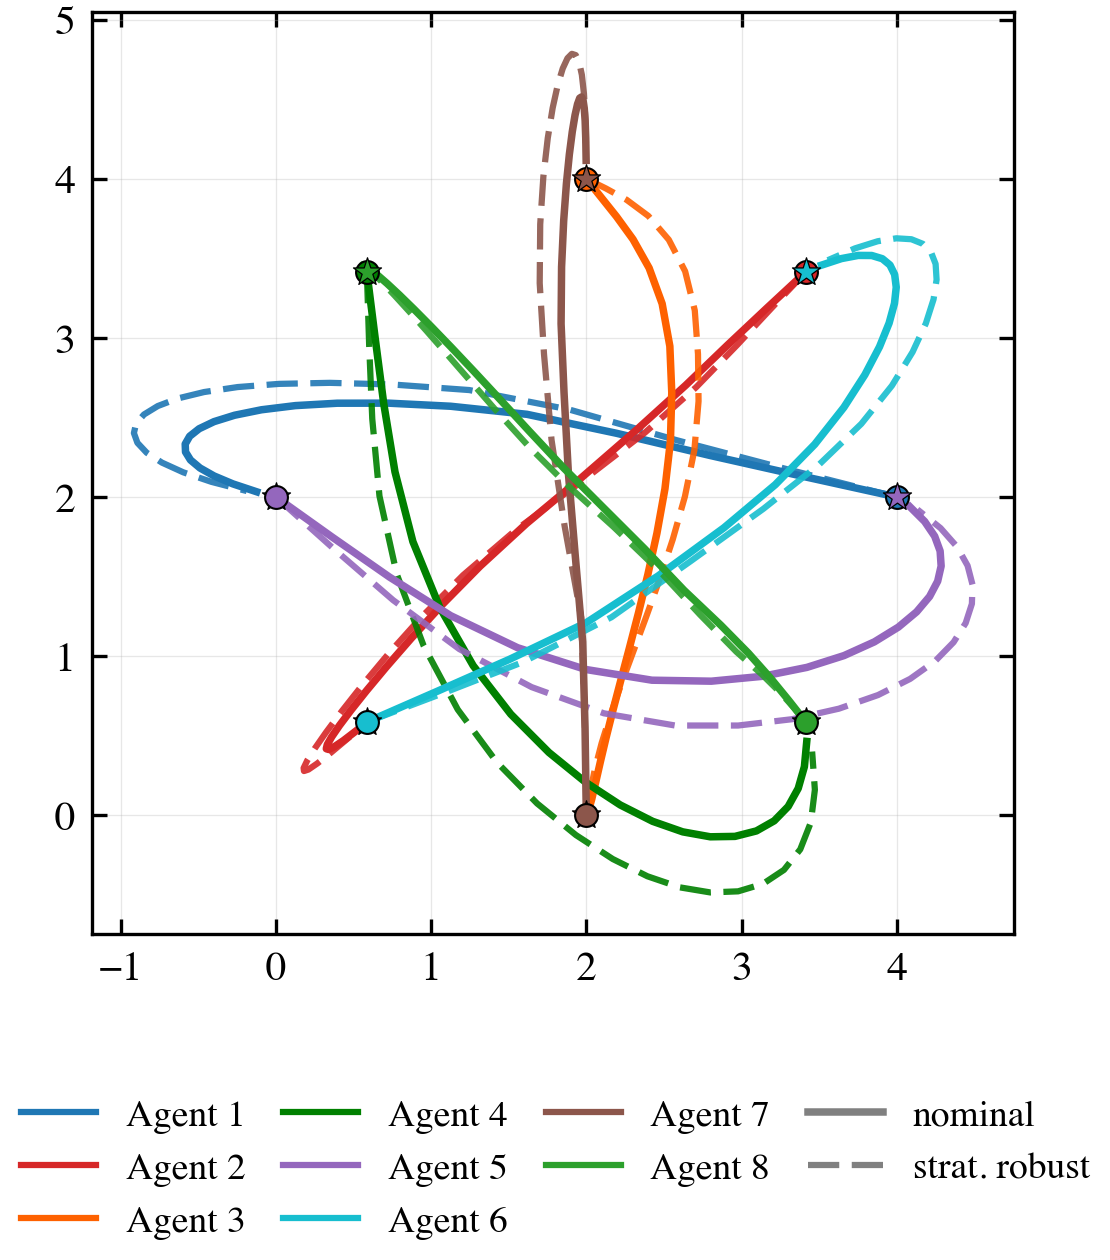

In [14]:
plotting.plot_trajectories(res8_nominal, [res8_robust], n_a8, H, sdim, cdim, xf_8,
                           method_labels=['nominal', 'strat. robust'],
                           save_path=FIGDIR / '8agent_trajectories.png')
plt.show()

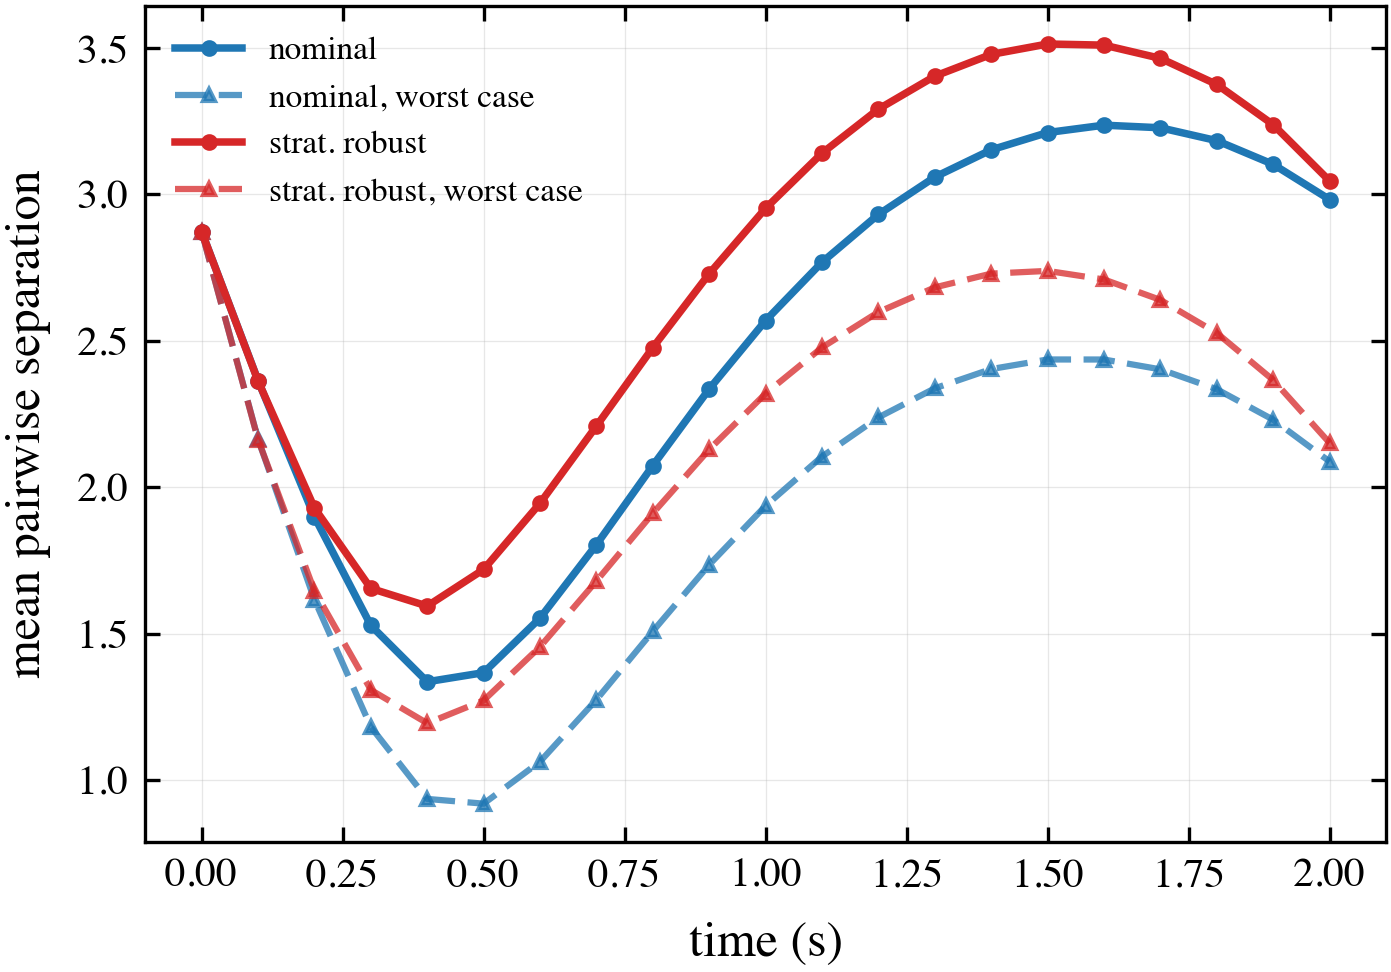

,min separation,"min separation, worst case"
method,,
nominal,0.4316,0.0226
strat. robust,0.4687,0.1859


In [15]:
plotting.plot_avg_distances([res8_nominal, res8_robust], ['nominal', 'strat. robust'],
                            n_a8, H, sdim, cdim, pdim, eps, A, B, dt,
                            save_path=FIGDIR / '8agent_separation.png')
plt.show()

pd.DataFrame(plotting.min_separation_table(
    [res8_nominal, res8_robust], ['nominal', 'strat. robust'],
    n_a8, H, sdim, cdim, pdim, eps, A, B)).set_index('method')

## 9. Runtime

`benchmark_tables.py` produces the paper's timing tables and is importable, so
the same code runs here and on a headless box. Three conventions in it are
worth knowing, each the result of a measurement that turned out to be wrong:

1. **Analytic gradients on every method**, including the nominal baseline and
   the nominal initialization inside the robust solve. Mixing modes made the
   8-agent robust overhead read 3.72x instead of 1.29x, because the
   finite-difference baseline stopped early on a worse optimum.
2. **Median reported next to mean.** One outlying run moved the 4-agent ratio
   from 1.89x to 1.72x under the mean. CV is printed so a noisy row is visible.
3. **Objectives recorded and checked for uniqueness.** If the runs in a cell
   did not all land on the same optimum, the spread is a mix of local minima
   rather than machine noise, and the row must not be averaged. The `uniq`
   column flags it.

The robust timing includes its own nominal initialization, so the ratio is the
honest end-to-end cost of switching methods, not the marginal cost of the
robust solve alone.

In [16]:
results_bench = [bench.run_scenario(name, BENCH_RUNS, verbose=False)
                 for name in ('Head-on', 'Parallel', '4 agents')]
results_bench.append(bench.run_scenario('8 agents', BENCH_RUNS_8, verbose=False))

rows = []
for r in results_bench:
    s = bench.summarize(r)
    for method in ('nominal', 'wider', 'robust'):
        rows.append({
            'scenario': r['scenario'], 'n_a': r['n_a'],
            'method': bench.LABEL[method],
            'median (s)': s[method]['median'],
            'ratio': s[method]['ratio_median'],
            'CV': s[method]['cv'],
            'iterations': s[method]['nit'],
            'path deviation': r['deviation'][method],
            'objective': s[method]['objective'],
            'uniq': s[method]['objective_unique'],
        })
runtime = pd.DataFrame(rows).set_index(['scenario', 'method'])
runtime

n_a  median (s)   ratio      CV  iterations  \
scenario method                                                       
Head-on  Nominal          2      0.2125  1.0000  0.0123        31.0   
         Wider            2      0.2387  1.1233  0.0137        35.0   
         Strat. Robust    2      0.3049  1.4347  0.0172        13.0   
Parallel Nominal          2      0.0611  1.0000  0.0078         9.0   
         Wider            2      0.0884  1.4475  0.0070        13.0   
         Strat. Robust    2      0.1033  1.6916  0.0343         6.0   
4 agents Nominal          4      0.9021  1.0000  0.0073        22.0   
         Wider            4      1.0658  1.1815  0.0021        26.0   
         Strat. Robust    4      1.6990  1.8835  0.0012        19.0   
8 agents Nominal          8     41.6625  1.0000  0.0002       131.0   
         Wider            8     26.9903  0.6478  0.0001        85.0   
         Strat. Robust    8     51.9970  1.2481  0.0013        32.0   

                        path deviation  objective  uniq  
scenario method                                          
Head-on  Nominal                0.0000    73.3080     1  
         Wider                  0.5159     8.3905     1  
         Strat. Robust          0.2523   116.4260     1  
Parallel Nominal                0.0000   128.6423     1  
         Wider                  0.4487     8.0438     1  
         Strat. Robust          0.1091   154.9635     1  
4 agents Nominal                0.0000   181.0621     1  
         Wider                  0.9532  -348.5486     1  
         Strat. Robust          0.4048   428.1921     1  
8 agents Nominal                0.0000    48.3576     1  
         Wider                  1.3598 -3496.1824     1  
         Strat. Robust          0.4213   902.5395     1

Every `uniq` above must be 1. Anything else means that cell mixed local minima
and its timings are not a like-for-like average.

The headline number is the `ratio` column on the **Strat. Robust** rows: the
multiple of nominal runtime that strategic robustness costs, end to end.

In [17]:
print(bench.format_tables(results_bench, stat='median'))


### Head-on  (n=5, ratios by median, full space)
method              mean   median     std     CV   nit   ratio  deviation           obj  uniq
---------------------------------------------------------------------------------------------
Nominal           0.2138   0.2125  0.0026  1.2%    31   1.00x     0.0000       73.3080     1
Wider             0.2401   0.2387  0.0033  1.4%    35   1.12x     0.5159        8.3905     1
Strat. Robust     0.3076   0.3049  0.0053  1.7%    13   1.43x     0.2523      116.4260     1

wall breakdown  measured overhead   total  share  per run
Nominal             1.07     0.42    1.49 32.6%    0.214
Wider               1.20     0.16    1.36 29.8%    0.240
Strat. Robust       1.54     0.18    1.72 37.5%    0.308
scenario total      3.81     0.77    4.58                  (unattributed +0.00s)

### Parallel  (n=5, ratios by median, full space)
method              mean   median     std     CV   nit   ratio  deviation           obj  uniq
---------------------------

## 10. Single shooting

The same problems can be solved over the controls alone, recovering states by
rolling the dynamics forward. That eliminates every equality constraint —
336 of them at 8 agents — and roughly halves the variable count.

The two parameterizations do not start from the same point: the full-space
default guess interpolates $x$ linearly with $u = 0$, a pair its own dynamics
do not produce, and shooting cannot represent an inconsistent start. On the
harder scenarios that is enough to reach a different local minimum, so the
objectives are worth comparing alongside the times.

In [18]:
t0 = time.perf_counter()
res8_nominal_s = optimize_optimal_shooting(*problem8, cost_nominal,
                                           distance_cost_grad_func=grad_nominal)
t8_nominal_s = time.perf_counter() - t0
_, u8_nom_s = split_solution(res8_nominal_s, n_a8, H, sdim, cdim)

t0 = time.perf_counter()
res8_robust_s = optimize_everystep_shooting(*problem8, eps, cost_nominal,
                                            distance_cost_grad_func=grad_nominal,
                                            u_opt=u8_nom_s)
t8_robust_s = time.perf_counter() - t0

pd.DataFrame([
    {'method': 'nominal', 'parameterization': 'full space',
     'seconds': t8_nominal, 'objective': res8_nominal.fun, 'iterations': res8_nominal.nit},
    {'method': 'nominal', 'parameterization': 'single shooting',
     'seconds': t8_nominal_s, 'objective': res8_nominal_s.fun, 'iterations': res8_nominal_s.nit},
    {'method': 'strat. robust', 'parameterization': 'full space',
     'seconds': t8_robust, 'objective': res8_robust.fun, 'iterations': res8_robust.nit},
    {'method': 'strat. robust', 'parameterization': 'single shooting',
     'seconds': t8_robust_s, 'objective': res8_robust_s.fun, 'iterations': res8_robust_s.nit},
]).set_index(['method', 'parameterization'])

seconds  objective  iterations
method        parameterization                                
nominal       full space        41.7343    48.3576         131
              single shooting    2.1070    36.6866          92
strat. robust full space        10.3132   902.5395          32
              single shooting    1.0431   884.7809          37

---

**Where to go next.** `adversary.py` documents the closed form for the worst
case. The appendix of `README.md` derives the other half — why the adversary's
response never appears in the gradient, since the envelope theorem removes it,
and how an earlier derivation that differentiated through the Riccati recursion
came out wrong by order 10. The paper gives the first half (Appendix B) but not
the second.